1. Use charts (histogram/bar graph) to display the distribution of types of statuses (photo,
video, link, and status)

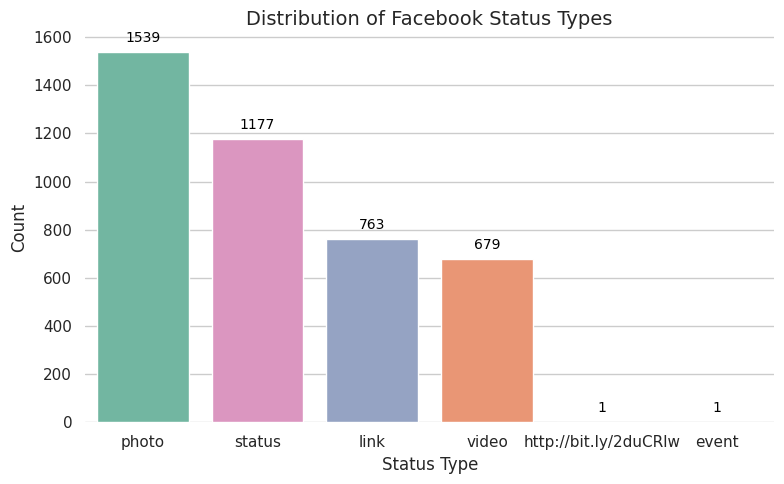

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the data set
df = pd.read_csv('Donald.csv')


# Plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='status_type',
    hue='status_type',
    order=df['status_type'].value_counts().index,
    palette='Set2',
    legend=False  # fixes the FutureWarning
)

# Addding count
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# labels and title
ax.set_title('Distribution of Facebook Status Types', fontsize=14)
ax.set_xlabel('Status Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

sns.despine(left=True, bottom=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Photo posts are the most common, with 1,539 posts, indicating that visual content is highly preferred. Text-based status posts follow closely, with 1,177 posts, suggesting people often share personal updates or thoughts in written form. Links make up 763 posts, showing a moderate amount of external content being shared, while videos, with 679 posts, are less frequent but still significant. The types labeled "http://bit.ly/2duCRIw" and "event" each have just one post, which may either be anomalies or placeholder entries.

2. Plot a chart showing the progression of likes, loves, and sads, and angrys over time.

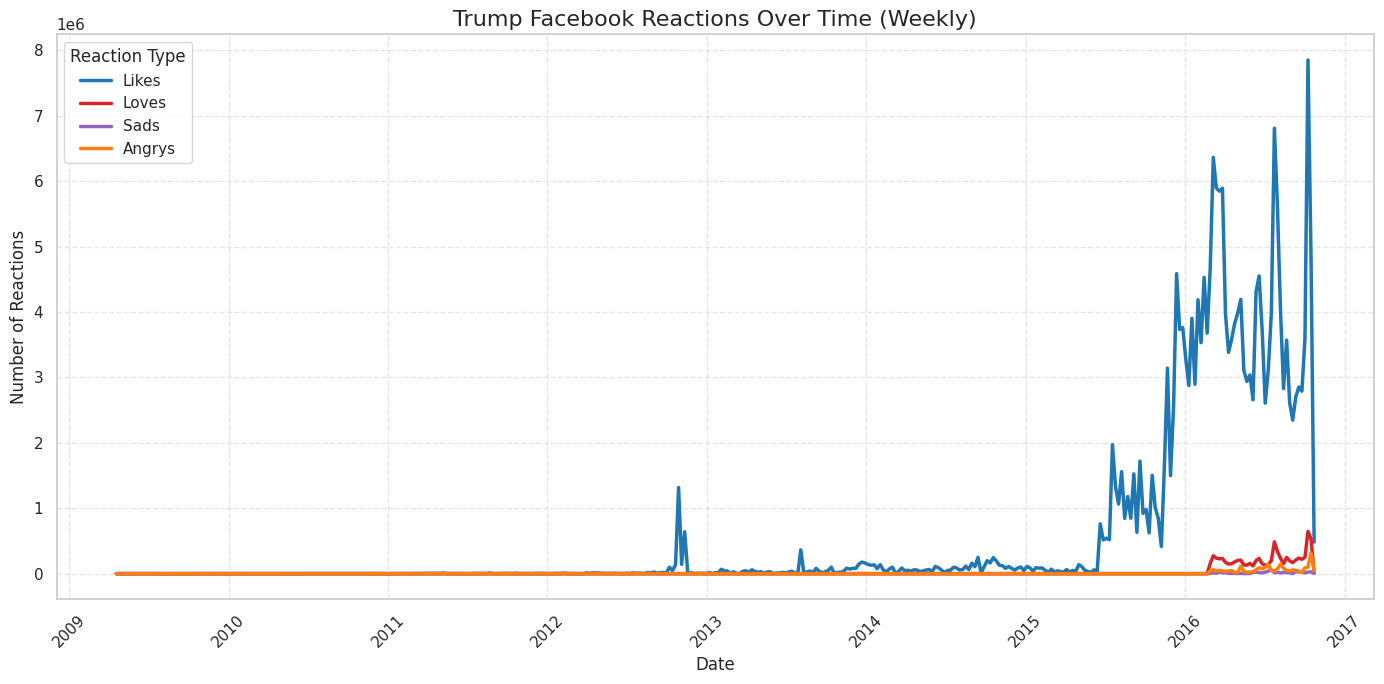

In [ ]:
# Converting to datetime
df['status_published'] = pd.to_datetime(df['status_published'], errors='coerce')

# droping missing and invalid data
df = df.dropna(subset=['status_published'])

# sorting and grouping by weeks
df = df.sort_values(by='status_published')
df_grouped = df.set_index('status_published').resample('W').sum()

# Plot
sns.set(style='whitegrid')
plt.figure(figsize=(14,7))

plt.plot(df_grouped.index, df_grouped['num_likes'], label='Likes', color='#1f77b4', linewidth=2.5)
plt.plot(df_grouped.index, df_grouped['num_loves'], label='Loves', color='#d62728', linewidth=2.5)
plt.plot(df_grouped.index, df_grouped['num_sads'], label='Sads', color='#9467bd', linewidth=2.5)
plt.plot(df_grouped.index, df_grouped['num_angrys'], label='Angrys', color='#ff7f0e', linewidth=2.5)


# Title and labels
plt.title('Trump Facebook Reactions Over Time (Weekly)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Reactions', fontsize=12)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Reaction Type', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()


Donald trump post started getting hate from earlier 2009 , he was being started liked and followed from 2013, which is picked in 2017, other reactions are induced in early 2016. All the reactions has grown over time but he is more liked since he 2013, and from the time likely when he announched presidency in 2015.

3. What are the top reactions expressed by Trump’s Facebook audience?

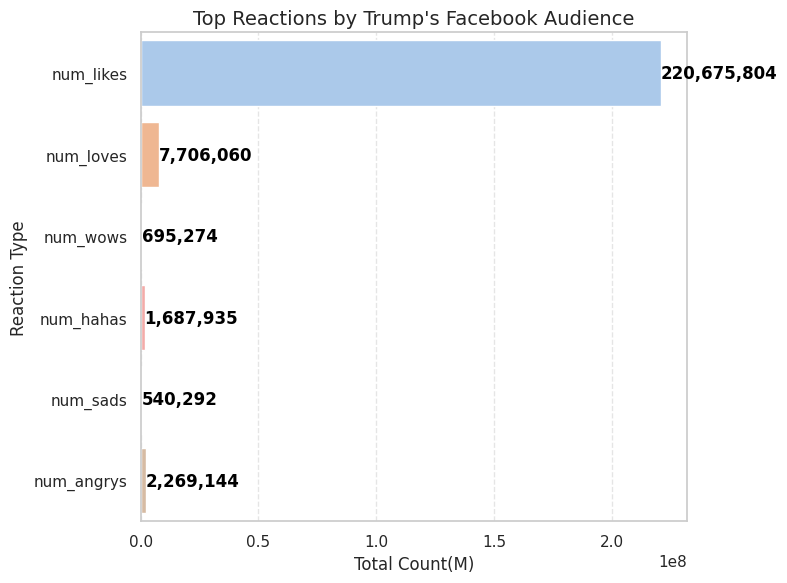

In [ ]:
reaction_columns = ['num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
reaction_totals = df[reaction_columns].sum()

# Converting to df for eaziness
reaction_df = reaction_totals.reset_index()
reaction_df.columns = ['Reaction', 'Count']

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(data=reaction_df, x='Count', y='Reaction', hue='Reaction', palette='pastel', dodge=False, legend=False)

# Adding counts labels
for i, v in enumerate(reaction_df['Count']):
    ax.text(v + 5000, i, f'{int(v):,}', color='black', va='center', fontweight='bold')

# Title and labels
plt.title("Top Reactions by Trump's Facebook Audience", fontsize=14)
plt.xlabel("Total Count(M)")
plt.ylabel("Reaction Type")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Trumps fans has mostly expressed liked expression , it means they agree with what ever sentiment or statement he is making , which is the majority by huge margin of total 22 millions .Then people have expressed love which is around 7M and followed by angry reaction which is 2 M, some people laughed around 1M  and around 500k felt sad in his statements.

4. Analyze the content in the status_message to find the top 10 topics (Topic modeling LDA
can be used). Can you tell if fans are particularly happy or upset about the topics?

Data preprocessing

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords')

# Preprocess text function
def preprocess_text(text):
    # only gets strings as text
    if not isinstance(text, str):
        return ""

    # Converting to lowercase
    text = text.lower()

    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

# Applying to preprocess
df['cleaned_status_message'] = df['status_message'].apply(preprocess_text)

# cleaned text
df[['status_message', 'cleaned_status_message']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,status_message,cleaned_status_message
4539,Watch Donald Trump on Good Morning America: ht...,watch donald trump good morning america httpab...
4538,Watch Donald J. Trump on Larry King Live: http...,watch donald j trump larry king live httpwwwcn...
4537,Follow Donald J. Trump on Twitter: http://twit...,follow donald j trump twitter httptwittercomre...
4536,#NAME?,name
4535,- Check out the official website for Donald Tr...,check official website donald trumps new book ...


LDA and Vectorization

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizing
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_status_message'])

# Fitting the LDA model
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

# Getting top words
n_words = 10
topic_words = {}
for topic_idx, topic in enumerate(lda.components_):
    topic_words[topic_idx] = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-n_words - 1:-1]]

# top words for topics
print("{")
for topic_idx, words in topic_words.items():
    print(f"    {topic_idx}: {words},")
print("}")


{
    0: ['watch', 'tonight', 'apprentice', 'nbc', 'video', 'great', 'miss', 'live', 'people', 'interview'],
    1: ['great', 'america', 'make', 'thank', 'safe', 'djt', 'love', 'support', 'going', 'movement'],
    2: ['hillary', 'clinton', 'people', 'american', 'country', 'jobs', 'want', 'law', 'going', 'americans'],
    3: ['trump', 'campaign', 'donald', 'presidential', 'president', 'delegates', 'cruz', 'obama', 'republican', 'tough'],
    4: ['new', 'jobs', 'going', 'american', 'people', 'country', 'trade', 'america', 'plan', 'clinton'],
    5: ['thank', 'great', 'america', 'new', 'support', 'vote', 'make', 'trump', 'makeamericagreatagain', 'trump2016'],
    6: ['hillary', 'clinton', 'great', 'america', 'crooked', 'make', 'people', 'time', 'country', 'trump'],
    7: ['cruz', 'ted', 'like', 'silent', 'think', 'mitt', 'romney', 'lyin', 'candidates', 'ads'],
    8: ['trump', 'donald', 'mr', 'golf', 'national', 'great', 'proud', 'international', 'eric', 'ivanka'],
    9: ['hillary', 'pr

The topic words suggest trump like to talk about america and criticize the opposition.Some other words include his personal life like golf , and people and jobs in america.

<ipython-input-53-ed42d93d283a>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts_series.index, y=topic_counts_series.values, palette='viridis',legend=False)


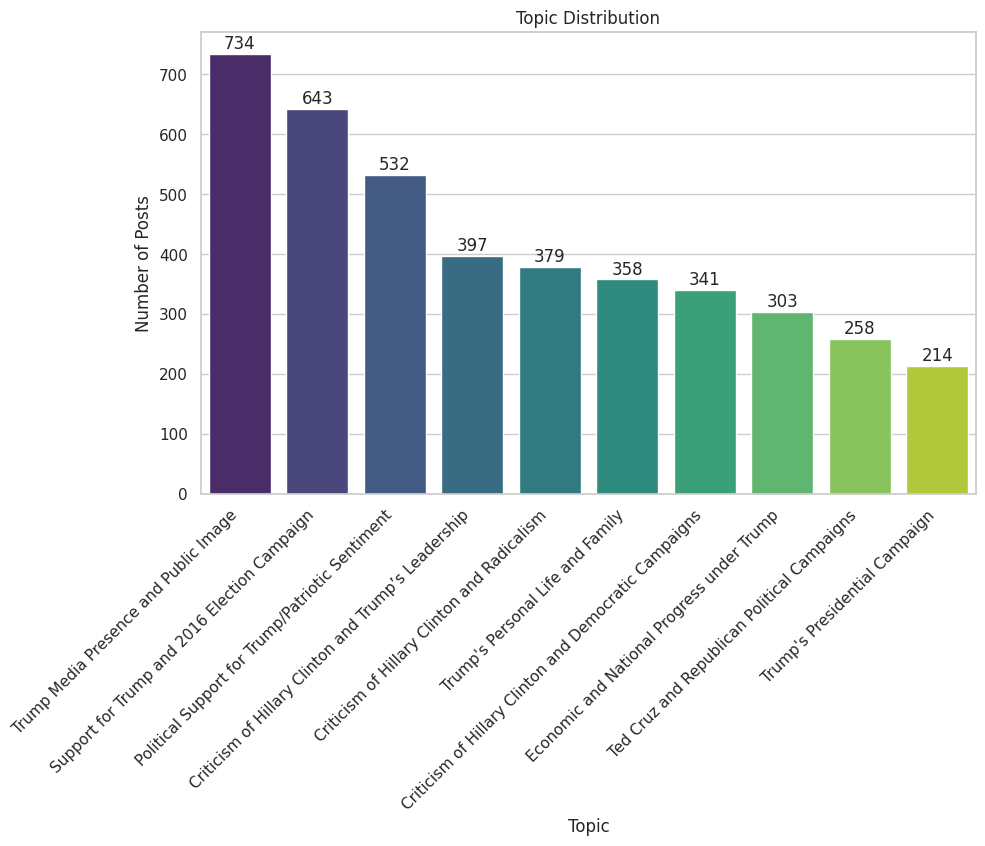

In [ ]:


topic_proportions = lda.transform(X)
topic_counts = topic_proportions.argmax(axis=1)

# Count the occurrences of each topic
topic_counts_series = pd.Series(topic_counts).value_counts()

# Giving the topic the labels
topic_labels = {
    0: "Trump Media Presence and Public Image",
    1: "Political Support for Trump/Patriotic Sentiment",
    2: "Criticism of Hillary Clinton and Democratic Campaigns",
    3: "Trump's Presidential Campaign",
    4: "Economic and National Progress under Trump",
    5: "Support for Trump and 2016 Election Campaign",
    6: "Criticism of Hillary Clinton and Trump’s Leadership",
    7: "Ted Cruz and Republican Political Campaigns",
    8: "Trump's Personal Life and Family",
    9: "Criticism of Hillary Clinton and Radicalism"
}

# Map topic labels to the topic counts
topic_counts_series = topic_counts_series.rename(index=topic_labels)

# Plot the topic counts
plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts_series.index, y=topic_counts_series.values, palette='viridis',legend=False)

# Add counts on top of the bars
for i, count in enumerate(topic_counts_series.values):
    plt.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=12)

plt.title('Topic Distribution')
plt.xlabel('Topic')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha="right")
plt.show()


I labeled the words into topics. It shows that Mr. Trump likes to create his media presence and image, talk about support for his election campaign, induce patriotic sentiments, criticize the opposition with radicalism, talk about his personal and family life, discuss his plans for economic and national progress, and criticize the opposition campaign. These topics are usually discussed in this order

Topic sentiments for fans

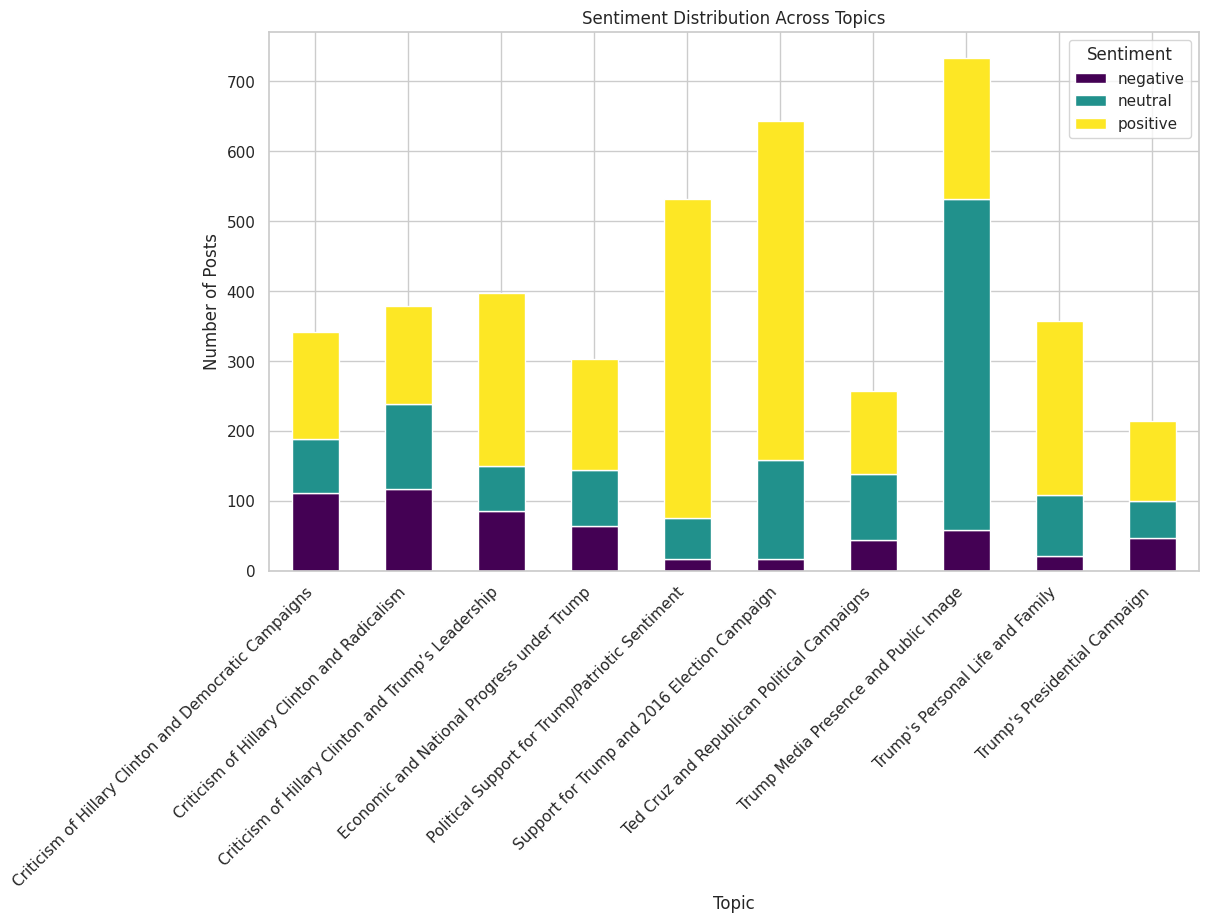

In [ ]:
# Handling nan values
df['status_message'] = df['status_message'].fillna('').astype(str)

# classify sentiment to positive, neutral, negative
def get_sentiment(text):
    blob = TextBlob(text)
    sentiment_score = blob.sentiment.polarity
    if sentiment_score > 0:
        return 'positive'
    elif sentiment_score == 0:
        return 'neutral'
    else:
        return 'negative'

# Applying the function
df['sentiment'] = df['status_message'].apply(get_sentiment)

# Add sentiment information to topics
df['topic'] = topic_counts
df['topic_label'] = df['topic'].map(topic_labels)

# Group by topic and sentiment to get counts
sentiment_counts_by_topic = df.groupby(['topic_label', 'sentiment']).size().unstack(fill_value=0)

# Plot
sentiment_counts_by_topic.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Sentiment Distribution Across Topics')
plt.xlabel('Topic')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.show()


The data suggest that fans are mostly happy about the topics but they seems mostly controversial as well because there is no topic that hasnot generated any negative sentiment .

What are the themes (topics or top words) that generated a lot of shares?

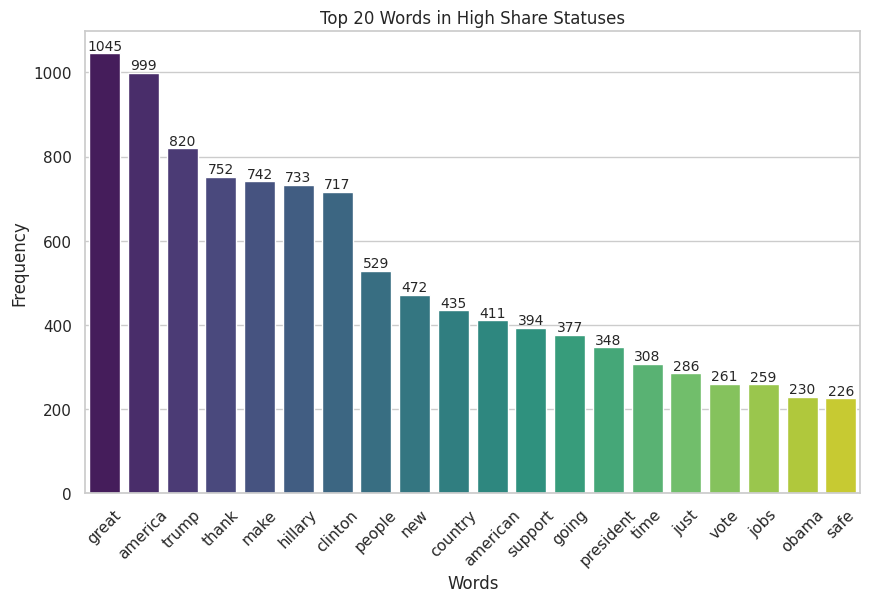

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

# Filter the dataset for posts with high shares
threshold = 150
high_share_posts = df[df['num_shares'] > threshold]

# Extracting the status messages
status_messages = high_share_posts['status_message']

# vectorize
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(status_messages)

# Getting the top words
top_words = vectorizer.get_feature_names_out()

# frequency of each word
word_counts = X.sum(axis=0).A1
word_freq = dict(zip(top_words, word_counts))

# Sortting
sorted_word_freq = dict(sorted(word_freq.items(), key=lambda item: item[1], reverse=True))
words = list(sorted_word_freq.keys())
counts = list(sorted_word_freq.values())

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=words, y=counts, hue=words, palette='viridis', legend=False)
plt.title('Top 20 Words in High Share Statuses')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

# Display
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.show()


Above words taking about making america great again , and criticizing oppositions looks like majority of content he talks about and also the words that are shared the most.

6. What are the themes (topics or top words) that generated a lot of num_reactions?

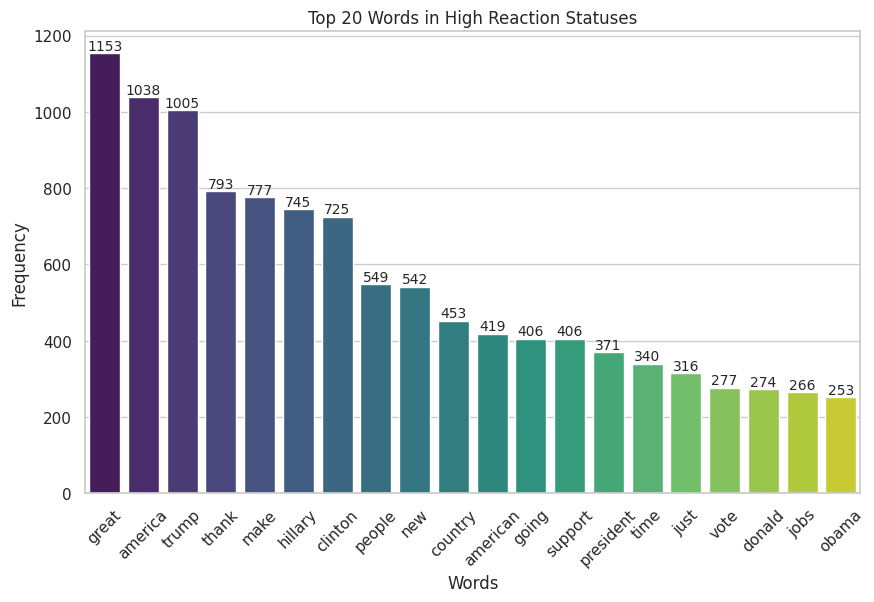

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Filtering the dataset for posts with high reactions
threshold = 100
high_reaction_posts = df[df['num_reactions'] > threshold]

# Extracting the status messages
status_messages = high_reaction_posts['status_message']

# vectorize
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(status_messages)

# Getting the top words
top_words = vectorizer.get_feature_names_out()

# Count the frequency of each word
word_counts = X.sum(axis=0).A1
word_freq = dict(zip(top_words, word_counts))

# Sortting
sorted_word_freq = dict(sorted(word_freq.items(), key=lambda item: item[1], reverse=True))
words = list(sorted_word_freq.keys())
counts = list(sorted_word_freq.values())

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=words, y=counts, hue=words, palette='viridis', legend=False)
plt.title('Top 20 Words in High Reaction Statuses')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

# Display
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.show()


like share,  words taking about making america great again , and criticizing oppositions looks like majority of content he talks about and also the words that have induced most reactions .